# Power Simulation with PyBaMM

This notebook demonstrates how to perform constant power discharge simulation using PyBaMM with BYD Blade Prismatic 135Ah cell parameters.

## Overview
- **Cell**: BYD Blade Prismatic 135Ah LFP
- **Chemistry**: LFP (Lithium Iron Phosphate)
- **Form Factor**: Prismatic
- **Nominal Voltage**: 3.3V
- **Capacity**: 135Ah
- **Simulations**: Constant power discharge at multiple power levels

In [1]:
# Import required libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm
from pathlib import Path
from model_library import simulate_power

## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [2]:
# Load cell manifest
manifest_path = Path("../cells/BYD_Blade_Prismatic_135Ah_manifest.json")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)

# ============================================================================
# OPERATING CONDITIONS FOR POWER TEST
# ============================================================================
power_config = {
    "temperature_K": 298.15,  # 25°C
    "initial_soc": 1.0,  # 100% SOC (full charge)
    "power_levels_W": [100, 200, 300, 400, 500, 750, 1000, 1250, 1500, 1750, 2000],  # Multiple power levels
    "lower_voltage_cutoff": 2.5,  # Lower voltage cutoff [V]
}

## 2. Run Power Simulation

Run the power simulation using the SPMe model with automatic capacity calibration at multiple power levels.

In [3]:
power_results = simulate_power(cell_design_manifest=cell_design_manifest, simulation_config=power_config)


Step 1: Updating cell parameters from manifest
  ✓ Design parameters updated
  ✓ Positive electrode parameters updated
  ✓ Negative electrode parameters updated
  ✓ Separator parameters updated
  ✓ Thermal parameters updated
  ✓ Operating conditions updated

Step 3: Capacity matching - Calibrating electrode width to match target capacity
Target capacity: 135.707 Ah
Maximum iterations: 20
Convergence tolerance: 0.010%

Starting iterative capacity matching...
--------------------------------------------------------------------------------
Iteration  1: Capacity = 142.73 Ah, Scale = 1.0518, Error =  5.178%
Iteration  2: Capacity = 135.64 Ah, Scale = 0.9995, Error =  0.051%
Iteration  3: Capacity = 135.71 Ah, Scale = 1.0000, Error =  0.001%
--------------------------------------------------------------------------------
✓ Converged after 3 iterations!
  Final capacity: 135.71 Ah
  Target capacity: 135.707 Ah
  Error: 0.0005%

Calibrated OCV window:
  OCV at 100% SOC: 3.4196 V
  OCV at 0% 

## 3. Visualize Results

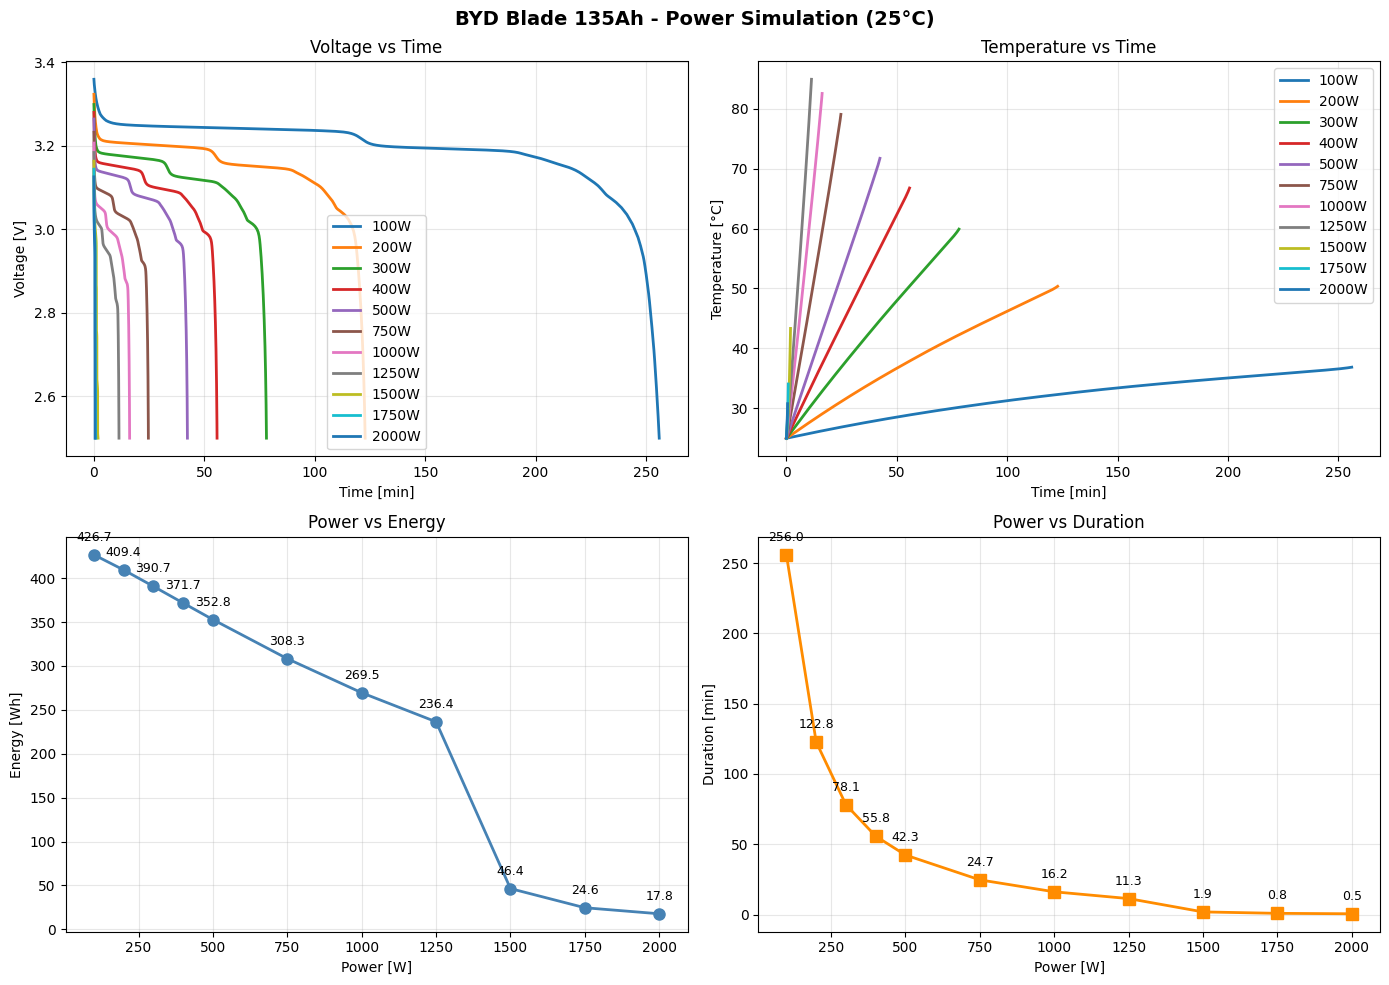

In [4]:
# Filter successful results
successful_results = [r for r in power_results if r['success']]

if len(successful_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Voltage vs Time for all power levels
    ax1 = axes[0, 0]
    for r in successful_results:
        time_min = (r['time_s'] - r['time_s'][0]) / 60
        ax1.plot(time_min, r['voltage_V'], linewidth=2, label=f"{r['power_W']}W")
    ax1.set_xlabel('Time [min]')
    ax1.set_ylabel('Voltage [V]')
    ax1.set_title('Voltage vs Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Temperature vs Time for all power levels
    ax2 = axes[0, 1]
    for r in successful_results:
        time_min = (r['time_s'] - r['time_s'][0]) / 60
        temp_C = r['temperature_K'] - 273.15
        ax2.plot(time_min, temp_C, linewidth=2, label=f"{r['power_W']}W")
    ax2.set_xlabel('Time [min]')
    ax2.set_ylabel('Temperature [°C]')
    ax2.set_title('Temperature vs Time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Power vs Energy
    ax3 = axes[1, 0]
    power_levels = [r['power_W'] for r in successful_results]
    energies = [r['discharge_energy_Wh'] for r in successful_results]
    ax3.plot(power_levels, energies, 'o-', linewidth=2, markersize=8, color='steelblue')
    ax3.set_xlabel('Power [W]')
    ax3.set_ylabel('Energy [Wh]')
    ax3.set_title('Power vs Energy')
    ax3.grid(True, alpha=0.3)
    # Add value labels
    for p, e in zip(power_levels, energies):
        ax3.annotate(f'{e:.1f}', (p, e), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

    # Plot 4: Power vs Duration
    ax4 = axes[1, 1]
    durations = [r['discharge_time_min'] for r in successful_results]
    ax4.plot(power_levels, durations, 's-', linewidth=2, markersize=8, color='darkorange')
    ax4.set_xlabel('Power [W]')
    ax4.set_ylabel('Duration [min]')
    ax4.set_title('Power vs Duration')
    ax4.grid(True, alpha=0.3)
    # Add value labels
    for p, d in zip(power_levels, durations):
        ax4.annotate(f'{d:.1f}', (p, d), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

    plt.suptitle(f'BYD Blade 135Ah - Power Simulation ({power_config["temperature_K"]-273.15:.0f}°C)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No successful simulations to plot.")

In [5]:
# Create summary DataFrame
if len(successful_results) > 0:
    summary_data = []
    for r in successful_results:
        summary_data.append({
            'Power [W]': r['power_W'],
            'Energy [Wh]': r['discharge_energy_Wh'],
            'Duration [min]': r['discharge_time_min'],
            'Max Temp [°C]': r['max_temperature_C'],
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\nPower Simulation Results:")
    print(summary_df.to_string(index=False))


Power Simulation Results:
 Power [W]  Energy [Wh]  Duration [min]  Max Temp [°C]
       100   426.666029      255.999617      36.863091
       200   409.410020      122.823006      50.362247
       300   390.682907       78.136581      59.903462
       400   371.721324       55.758199      66.763250
       500   352.848826       42.341859      71.720858
       750   308.298189       24.663855      79.053706
      1000   269.512451       16.170747      82.546831
      1250   236.434892       11.348875      84.910870
      1500    46.449634        1.857985      43.333398
      1750    24.636696        0.844687      34.056902
      2000    17.763165        0.532895      30.771933
